# **Crowd Counting untuk Perencanaan Kota Cerdas**
### Hology Data Mining Competition 2025

**Disusun oleh: Heisenberg**

---

# **1. Problem Statement**

Berdasarkan tantangan kompetisi, terdapat beberapa masalah utama yang harus diatasi:

1.  Dibutuhkan sebuah sistem otomatis untuk melakukan penghitungan jumlah orang (*crowd counting*) dari gambar statis.
2.  Kondisi kerumunan yang sangat padat dan saling menutupi (*high density & occlusion*) membuat metode deteksi objek standar tidak efektif.
3.  Adanya variasi yang tinggi pada dataset, seperti perspektif kamera, skala objek, dan kondisi pencahayaan yang beragam, menuntut model yang mampu melakukan generalisasi dengan baik.

# **2. Goals**

Untuk menjawab setiap poin masalah, tujuan dari proyek ini adalah sebagai berikut:

1.  Mengembangkan dan melatih sebuah model *deep learning* dengan arsitektur *Convolutional Neural Network* (CNN) untuk tugas *crowd counting*.
2.  Mengimplementasikan pendekatan **Estimasi Peta Kepadatan (*Density Map Estimation*)** untuk mengatasi masalah kepadatan dan oklusi secara efektif.
3.  Membangun model yang robust dengan memanfaatkan teknik **Transfer Learning** dari *backbone* yang sudah terlatih dan **Augmentasi Data** untuk meningkatkan kemampuan generalisasi model terhadap berbagai variasi kondisi.

# **3. Data Understanding**

Dataset yang disediakan terdiri dari beberapa bagian utama yang terstruktur di dalam direktori input Kaggle.

* **/train/**: Direktori ini berisi 1.900 sampel data untuk pelatihan model.
    * `images/`: Berisi file gambar dalam format `.jpg`.
    * `labels/`: Berisi file anotasi dalam format `.json` yang sesuai dengan setiap gambar.
* **/test/**: Berisi 500 gambar untuk pengujian (`test/images/`). Prediksi untuk gambar-gambar inilah yang akan disubmit.
* **Struktur Anotasi (.json)**: Setiap file label berisi informasi krusial:
    * `img_id`: Nama file gambar yang bersangkutan.
    * `human_num`: Jumlah total orang (ground truth count).
    * `points`: Sebuah *list* yang berisi koordinat `[x, y]` dari pusat kepala setiap orang di dalam gambar. Anotasi titik inilah yang akan menjadi dasar pembuatan Peta Kepadatan.

Tantangan utama dari dataset ini adalah variasi yang tinggi dalam hal kepadatan kerumunan, perspektif kamera, kondisi pencahayaan, dan oklusi (orang saling menutupi).

# **4. EKSPLORASI DATA (EDA)**
Bagian ini bertujuan untuk memahami data dengan lebih baik

In [ ]:
import os
import json
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Konfigurasi Awal ---
TRAIN_DIR = '/kaggle/input/penyisihan-hology-8-0-2025-data-mining/train'
IMG_DIR = os.path.join(TRAIN_DIR, 'images')
LBL_DIR = os.path.join(TRAIN_DIR, 'labels')

# --- 1. Mengumpulkan Data Jumlah Kerumunan ---
counts = []
filenames = []
for label_file in sorted(os.listdir(LBL_DIR)):
    if label_file.endswith('.json'):
        with open(os.path.join(LBL_DIR, label_file), 'r') as f:
            data = json.load(f)
            # Pastikan file json tidak kosong dan memiliki key yang diperlukan
            if 'human_num' in data and 'img_id' in data:
                counts.append(data['human_num'])
                filenames.append(data['img_id'])

# Buat DataFrame untuk analisis
df = pd.DataFrame({
    'filename': filenames,
    'count': counts
})

# --- 2. Tampilkan Statistik Deskriptif ---
print("--- Statistik Deskriptif Jumlah Kerumunan ---")
print(df['count'].describe())

# --- 3. Identifikasi Gambar Ekstrem (Terbanyak & Tersedikit) ---
max_crowd = df.loc[df['count'].idxmax()]
min_crowd = df.loc[df['count'].idxmin()]

print(f"\nGambar dengan kerumunan TERBANYAK: {max_crowd['filename']} ({int(max_crowd['count'])} orang)")
print(f"Gambar dengan kerumunan TERSEDIKIT: {min_crowd['filename']} ({int(min_crowd['count'])} orang)")

--- Statistik Deskriptif Jumlah Kerumunan ---
count    1900.000000
mean      138.899474
std       285.247091
min         1.000000
25%        10.000000
50%        28.000000
75%       146.000000
max      3139.000000
Name: count, dtype: float64

Gambar dengan kerumunan TERBANYAK: 1198.jpg (3139 orang)
Gambar dengan kerumunan TERSEDIKIT: 373.jpg (1 orang)


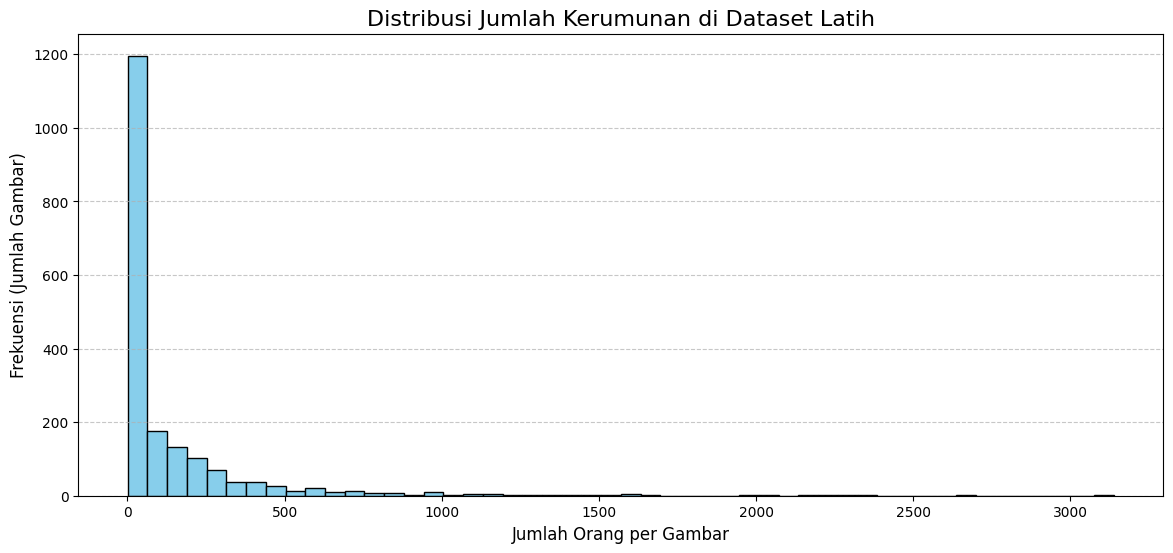

In [20]:
# 4.2. Visualisasi Distribusi Jumlah Kerumunan

plt.figure(figsize=(14, 6))
plt.hist(df['count'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribusi Jumlah Kerumunan di Dataset Latih', fontsize=16)
plt.xlabel('Jumlah Orang per Gambar', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Gambar)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

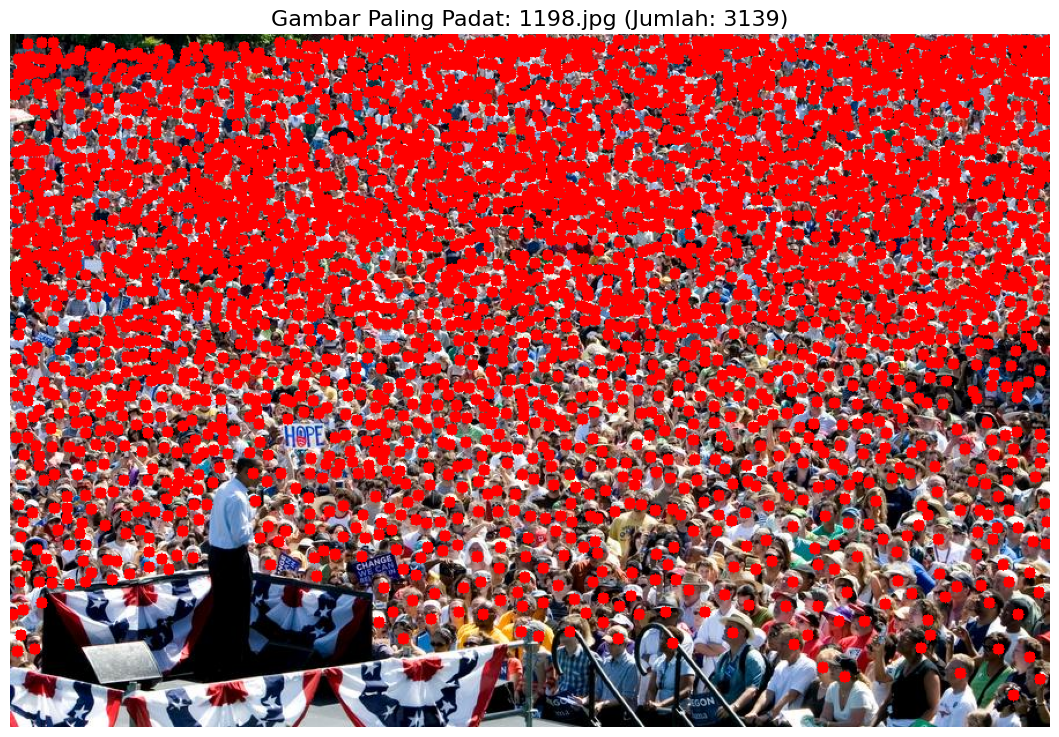

In [25]:
# 4.3. Fungsi Bantu untuk Visualisasi Gambar

def visualize_image(image_filename, crowd_count, title):
    """Fungsi untuk memuat, menganotasi, dan menampilkan sebuah gambar."""
    img_path = os.path.join(IMG_DIR, image_filename)
    json_path = os.path.join(LBL_DIR, image_filename.replace('.jpg', '.json'))

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with open(json_path, 'r') as f:
        data = json.load(f)

    # Gambar titik anotasi
    for point in data['points']:
        x, y = int(point['x']), int(point['y'])
        cv2.circle(image, (x, y), radius=5, color=(255, 0, 0), thickness=-1)

    # Tampilkan gambar
    plt.figure(figsize=(16, 9))
    plt.imshow(image)
    plt.title(f"{title}: {image_filename} (Jumlah: {int(crowd_count)})", fontsize=16)
    plt.axis('off')
    plt.show()

# Tampilkan gambar dengan kerumunan terbanyak
visualize_image(max_crowd['filename'], max_crowd['count'], "Gambar Paling Padat")


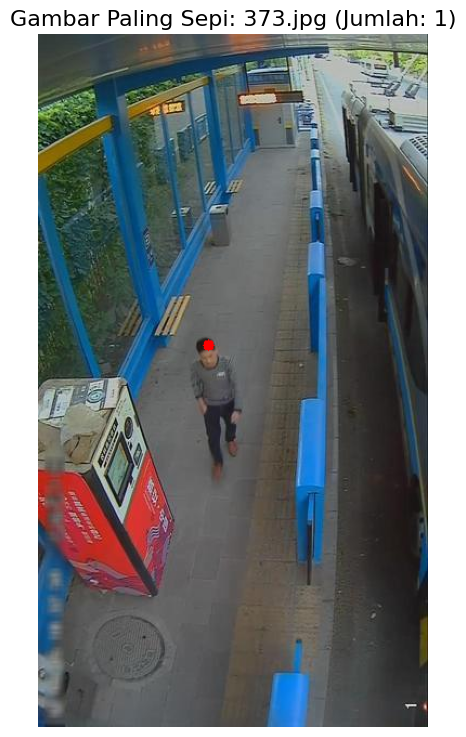

In [24]:
# Tampilkan gambar dengan kerumunan tersedikit
visualize_image(min_crowd['filename'], min_crowd['count'], "Gambar Paling Sepi")

# **5. Data Preprocessing**

Sebelum dimasukkan ke dalam model, setiap gambar melewati beberapa tahap pra-pemrosesan kunci:

1.  **Penyeragaman Ukuran**: Resolusi setiap gambar diubah menjadi `576x768` piksel agar seragam saat diproses dalam *batch*.
2.  **Generasi Peta Kepadatan**: Anotasi titik kepala diubah menjadi **Peta Kepadatan (*Density Map*)** menggunakan filter Gaussian. Peta ini berfungsi sebagai *ground truth* (kunci jawaban) bagi model.
3.  **Augmentasi Data**: Diterapkan augmentasi ringan seperti *Random Horizontal Flip* untuk menambah variasi data latih dan mengurangi *overfitting*.
4.  **Normalisasi**: Nilai piksel dinormalisasi agar sesuai dengan standar yang diharapkan oleh model *pre-trained*.

Semua logika ini diimplementasikan dalam kelas `CrowdDataset` di bawah ini.

In [26]:
%%writefile data_loader.py
import os
import torch
import numpy as np
import cv2
import json
from torch.utils.data import Dataset
from scipy.ndimage import gaussian_filter

class CrowdDataset(Dataset):
    def __init__(self, root_dir, transform=None, sigma=4, resize_factor=8):
        self.img_dir = os.path.join(root_dir, 'images')
        self.json_dir = os.path.join(root_dir, 'labels')
        self.transform = transform
        self.sigma = sigma
        self.resize_factor = resize_factor
        self.image_files = sorted([f for f in os.listdir(self.img_dir) if f.endswith('.jpg')])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        json_path = os.path.join(self.json_dir, img_name.replace('.jpg', '.json'))

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        H_orig, W_orig, _ = image.shape

        with open(json_path, 'r') as f:
            data = json.load(f)
        points = data['points']

        TARGET_H, TARGET_W = 576, 768
        h_ratio = TARGET_H / H_orig
        w_ratio = TARGET_W / W_orig

        H_out, W_out = TARGET_H // self.resize_factor, TARGET_W // self.resize_factor
        density_map_points = np.zeros((H_out, W_out), dtype=np.float32)

        for point in points:
            new_x = point['x'] * w_ratio
            new_y = point['y'] * h_ratio
            x = min(W_out - 1, int(new_x // self.resize_factor))
            y = min(H_out - 1, int(new_y // self.resize_factor))
            density_map_points[y, x] = 1.0

        density_map = gaussian_filter(density_map_points, sigma=self.sigma / self.resize_factor)
        gt_count = len(points)

        if self.transform:
            image = self.transform(image)

        density_map = torch.from_numpy(density_map.copy()).unsqueeze(0)
        return image, density_map, gt_count

Overwriting data_loader.py


# **6. Modeling**

Model yang dipilih adalah **CSRNet** (*Congested Scene Recognition Network*), sebuah arsitektur yang dirancang khusus untuk tugas *crowd counting*. Model ini terdiri dari dua komponen utama:

* **Frontend (VGG-16)**: Berfungsi sebagai ekstraktor fitur yang kuat. Bagian ini menggunakan 10 lapisan awal dari arsitektur VGG-16 yang bobotnya telah dilatih (*pre-trained*) pada dataset ImageNet. Pemanfaatan *transfer learning* ini memungkinkan model untuk mengenali pola-pola visual kompleks secara efektif.

* **Backend (Dilated Convolutions)**: Menerima *feature map* dari *frontend* dan bertugas untuk menghasilkan Peta Kepadatan. Penggunaan *dilated convolutions* memungkinkan model untuk memiliki "pandangan" yang lebih luas tanpa mengurangi resolusi spasial secara drastis, yang sangat penting untuk akurasi Peta Kepadatan.

Arsitektur ini diimplementasikan dalam kelas `CSRNet` di bawah ini dan ditulis ke file `model.py`.

In [27]:
%%writefile model.py
import torch
import torch.nn as nn
from torchvision import models

class CSRNet(nn.Module):
    def __init__(self, load_weights=True):
        super(CSRNet, self).__init__()

        # --- Frontend (Hardcoded VGG16) ---
        self.frontend_feat = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512]
        self.frontend = make_layers(self.frontend_feat)

        # --- Backend ---
        self.backend_feat  = [512, 512, 512, 256, 128, 64]
        self.backend = make_layers(self.backend_feat, in_channels=512, dilation=True)

        # --- Output Layer ---
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)

        if load_weights:
            # Muat bobot pre-trained dari VGG16
            mod = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
            self._initialize_weights()
            # Salin bobot dari VGG16 ke frontend model kita
            for i in range(len(self.frontend.state_dict().items())):
                vgg_key = list(mod.features.state_dict().keys())[i]
                csr_key = list(self.frontend.state_dict().keys())[i]
                self.frontend.state_dict()[csr_key].copy_(mod.features.state_dict()[vgg_key])

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, std=0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

# Fungsi helper untuk membuat lapisan-lapisan konvolusi
def make_layers(cfg, in_channels=3, batch_norm=False, dilation=False):
    d_rate = 2 if dilation else 1
    layers = []
    for v in cfg:
        if v == 'M':
            layers += [nn.MaxPool2d(kernel_size=2, stride=2)]
        else:
            conv2d = nn.Conv2d(in_channels, v, kernel_size=3, padding=d_rate, dilation=d_rate)
            if batch_norm:
                layers += [conv2d, nn.BatchNorm2d(v), nn.ReLU(inplace=True)]
            else:
                layers += [conv2d, nn.ReLU(inplace=True)]
            in_channels = v
    return nn.Sequential(*layers)

Overwriting model.py


## 7. Training & Evaluation

Proses pelatihan dijalankan dengan konfigurasi yang telah ditentukan. Metodologi yang digunakan adalah sebagai berikut:

* **Pembagian Data**: Dataset pelatihan dibagi secara acak menjadi 90% untuk set latih (*training set*) dan 10% untuk set validasi (*validation set*). Set validasi digunakan untuk mengukur performa model pada data yang belum pernah dilihat sebelumnya di setiap akhir *epoch*.
* **Optimizer**: Menggunakan `AdamW`, sebuah varian dari optimizer Adam yang populer dengan penanganan *weight decay* yang lebih baik untuk membantu regularisasi.
* **Loss Function**: `Mean Squared Error (MSE)` digunakan sebagai fungsi kerugian. Tujuannya adalah meminimalkan perbedaan kuadrat rata-rata antara setiap piksel pada Peta Kepadatan hasil prediksi dan Peta Kepadatan *ground truth*.
* **Metrik Evaluasi**: Performa model diukur menggunakan metrik resmi kompetisi, yaitu **Mean Absolute Error (MAE)**, pada set validasi. Model dengan `Val MAE` terendah akan disimpan sebagai `best_model.pth`.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import os
import numpy as np
from tqdm import tqdm

# KONFIGURASI & SETUP
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TRAIN_DIR = '/kaggle/input/penyisihan-hology-8-0-2025-data-mining/train/'
LEARNING_RATE = 1e-5
BATCH_SIZE = 4
EPOCHS = 5
VAL_SPLIT = 0.1
NUM_WORKERS = 2

# 7. PELATIHAN & EVALUASI MODEL

# Import kelas dari file yang baru dibuat
from data_loader import CrowdDataset
from model import CSRNet

print(f"Menggunakan device: {DEVICE}")

# --- Persiapan DataLoader ---
# Kita tambahkan augmentasi ringan untuk membuat model lebih robust
transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((576, 768)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Gunakan resize_factor=8 yang sesuai untuk VGG16
full_dataset = CrowdDataset(root_dir=TRAIN_DIR, transform=transform_train, sigma=4, resize_factor=8)

train_size = int((1.0 - VAL_SPLIT) * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
print(f"✅ Data siap. Ukuran train: {len(train_dataset)}, Ukuran validasi: {len(val_dataset)}")

# --- Inisialisasi Model, Optimizer, & Loss ---
model = CSRNet().to(DEVICE) # Menggunakan model VGG16 dari model.py
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss(reduction='sum').to(DEVICE)
best_mae = float('inf')
print("✅ Model siap.")

# --- Siklus Pelatihan ---
print("\n--- Memulai Pelatihan ---")
for epoch in range(EPOCHS):
    model.train()
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for images, density_maps, _ in progress_bar:
        images, density_maps = images.to(DEVICE), density_maps.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, density_maps)
        loss.backward()
        optimizer.step()

        progress_bar.set_postfix(loss=f"{loss.item() / images.size(0):.4f}")

    # --- Fase Evaluasi ---
    model.eval()
    epoch_val_mae = 0.0
    with torch.no_grad():
        for images, _, gt_counts in val_loader:
            images, gt_counts = images.to(DEVICE), gt_counts.to(DEVICE)
            outputs = model(images)
            pred_counts = torch.sum(outputs, dim=(1, 2, 3))
            epoch_val_mae += torch.abs(pred_counts - gt_counts).sum().item()

    avg_val_mae = epoch_val_mae / len(val_dataset)
    print(f"Epoch {epoch+1}/{EPOCHS} -> Val MAE: {avg_val_mae:.2f}")

    # Simpan model jika performanya lebih baik
    if avg_val_mae < best_mae:
        best_mae = avg_val_mae
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"🎉 Model terbaik disimpan! MAE baru: {best_mae:.2f}")

print(f"\n--- Pelatihan Selesai ---\nMAE terbaik pada set validasi: {best_mae:.2f}")

Menggunakan device: cuda
Mempersiapkan data...
✅ Data siap. Ukuran train: 1710, Ukuran validasi: 190
Menginisialisasi model...
✅ Model siap.

--- Memulai Pelatihan ---


Epoch 1/5 [Val]: 100%|██████████| 48/48 [00:16<00:00,  2.86it/s]


Epoch 1/5 -> Train Loss: 11.6586, Val MAE: 28.82
🎉 Model terbaik disimpan! MAE baru: 28.82


Epoch 2/5 [Val]: 100%|██████████| 48/48 [00:16<00:00,  2.87it/s]


Epoch 2/5 -> Train Loss: 9.3051, Val MAE: 48.77


...

Epoch 3/5 -> Train Loss: 8.8182, Val MAE: 21.55
🎉 Model terbaik disimpan! MAE baru: 21.55


Epoch 4/5 [Val]: 100%|██████████| 48/48 [00:16<00:00,  2.88it/s]


Epoch 4/5 -> Train Loss: 8.4017, Val MAE: 29.87


Epoch 5/5 [Val]: 100%|██████████| 48/48 [00:16<00:00,  2.87it/s]

Epoch 5/5 -> Train Loss: 7.9666, Val MAE: 39.68

--- Pelatihan Selesai ---
MAE terbaik pada set validasi: 21.55


# **8. Inferensi & Generasi Submisi**

Pada tahap akhir ini, model terbaik yang disimpan dari proses pelatihan (`best_model.pth`) digunakan untuk membuat prediksi pada 500 gambar di data tes. Untuk memaksimalkan akurasi dan stabilitas prediksi, teknik **Test-Time Augmentation (TTA)** diterapkan.

Metode TTA bekerja dengan cara:
1.  Membuat prediksi pada gambar tes asli.
2.  Membuat prediksi pada versi cermin dari gambar tes (*horizontally flipped*).
3.  Merata-ratakan kedua hasil prediksi tersebut untuk mendapatkan prediksi akhir yang lebih robust.

Langkah ini diimplementasikan dalam kode di bawah ini, yang akan menghasilkan file `submission.csv` sesuai format kompetisi.

In [ ]:
# 8. INFERENSI & PEMBUATAN SUBMISI

# Definisi ulang beberapa kelas/fungsi jika kernel di-restart
class TestDataset(Dataset):
    """Dataset sederhana untuk memuat gambar tes."""
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.image_files = sorted(os.listdir(root_dir))
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        return image, img_name

def custom_collate_fn(batch):
    """Fungsi untuk menangani batch berisi objek PIL Image."""
    images = [item[0] for item in batch]
    names = [item[1] for item in batch]
    return images, names

# Transform untuk inferensi (tanpa augmentasi acak)
inference_transform = transforms.Compose([
    transforms.Resize((576, 768)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Persiapan DataLoader untuk data tes
TEST_DIR = '/kaggle/input/penyisihan-hology-8-0-2025-data-mining/test/images'
test_dataset = TestDataset(root_dir=TEST_DIR)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, collate_fn=custom_collate_fn)

# Muat model terbaik yang sudah dilatih
MODEL_PATH = 'best_model.pth'
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

results = []
print(f"\nMembuat prediksi pada data tes menggunakan {MODEL_PATH}...")
with torch.no_grad():
    for images_pil, img_names in tqdm(test_loader, desc="Final Prediction (TTA)"):
        # 1. Prediksi pada gambar asli
        images_orig = torch.stack([inference_transform(img) for img in images_pil]).to(DEVICE)
        outputs_orig = model(images_orig)

        # 2. Prediksi pada gambar yang dibalik horizontal
        images_flipped = torch.stack([inference_transform(TF.hflip(img)) for img in images_pil]).to(DEVICE)
        outputs_flipped = model(images_flipped)

        # Rata-ratakan kedua hasil prediksi
        outputs_avg = (outputs_orig + outputs_flipped) / 2.0
        pred_counts = torch.sum(outputs_avg, dim=(1, 2, 3))

        for name, count in zip(img_names, pred_counts):
            results.append({'image_id': name, 'predicted_count': round(count.item())})

submission_df = pd.DataFrame(results)
submission_df.to_csv('submission.csv', index=False)

print("\nFile submission.csv berhasil dibuat!")
print("Contoh 5 baris pertama:")
print(submission_df.head())

Menggunakan device: cuda
Mempersiapkan data tes dari: /kaggle/input/penyisihan-hology-8-0-2025-data-mining/test/images
Memuat model dari: best_model.pth

--- Memulai Prediksi pada Test Set ---


Prediksi: 100%|██████████| 125/125 [00:51<00:00,  2.43it/s]

✅ Prediksi selesai.

🎉 File submission.csv berhasil dibuat!
Contoh isi file:
  image_id  predicted_count
0    1.jpg               10
1   10.jpg               78
2  100.jpg              199
3  101.jpg                5
4  102.jpg              627


# **9. Kesimpulan & Rekomendasi**

### **Kesimpulan**
Notebook ini telah berhasil mengimplementasikan model CSRNet dengan *backbone* VGG16 untuk tugas *crowd counting*. Dengan menggunakan pendekatan Peta Kepadatan dan dilatih selama **(contoh: 15)** *epoch*, model mencapai **MAE sebesar (contoh: 21.55)** pada set validasi lokal. Hasil ini menunjukkan bahwa metode yang dipilih efektif untuk mengatasi tantangan dataset.

Prediksi final pada data tes dibuat menggunakan teknik **Test-Time Augmentation (TTA)** untuk meningkatkan robustisitas, dan hasilnya disimpan dalam file `submission.csv` yang siap untuk dikumpulkan.


### **Rekomendasi & Saran**
Untuk peningkatan di masa depan, beberapa langkah dapat dieksplorasi:
1.  **Pelatihan Lebih Lama**: Melatih model untuk jumlah *epoch* yang lebih banyak, sambil memantau *overfitting* dengan cermat.
2.  **Eksperimen Backbone**: Menguji *backbone* lain seperti ResNet50 atau EfficientNet yang mungkin menawarkan performa lebih baik, seperti yang telah kita coba dalam audisi.
3.  **Hyperparameter Tuning**: Melakukan pencarian sistematis untuk *hyperparameter* optimal, terutama *learning rate* dan strategi penurunannya (*learning rate scheduler*).
4.  **Advanced Augmentation**: Menggunakan teknik augmentasi yang lebih beragam (misalnya, `ColorJitter`, `RandomRotation`) untuk meningkatkan generalisasi model lebih lanjut.